**Lab 5: FIR Filtering 2**

The goal of this lab is to study the response of FIR filters to inputs such as complex exponentials and sinusoids. In the experiments of this lab, you will use `np.convolve()` to implement filters and `freqz()` to obtain the filter’s frequency response. As a result, you should learn how to characterize a filter by knowing how it reacts to different frequency components in the input.
This lab also introduces two practical filters: bandpass filters and nulling filters.
Bandpass filters can be used to detect and extract information from complex signals,
e.g., tones in a touch-tone telephone dialer. Nulling filters can be used to remove
sinusoidal interference, e.g., jamming signals in a radar.

In [1]:
import os
import numpy as np
import librosa
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram

1.1. First, let's replicate what we did until now. Copy the functions synthesize and envelope and obtain the synthesis from the last lab.

In [2]:
import numpy as np

def envelope(x, N):
    """
    Extracts the envelope of the input signal x by concatenating 
    a full-wave rectifier and an N-point averaging filter.

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    N : int
        The number of points used in N-point averaging filter

    Returns
    -------
    y : np.array
        The output of the system, i.e., the envelope of the signal x.
    """
    x_rectified = np.abs(x)
    b = np.ones(N) / N
    y = np.convolve(x_rectified, b, mode='same')

    return y

def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y

1.2 Plot both reference and synthesised signal.

fatal: destination path 'sis1-group202' already exists and is not an empty directory.


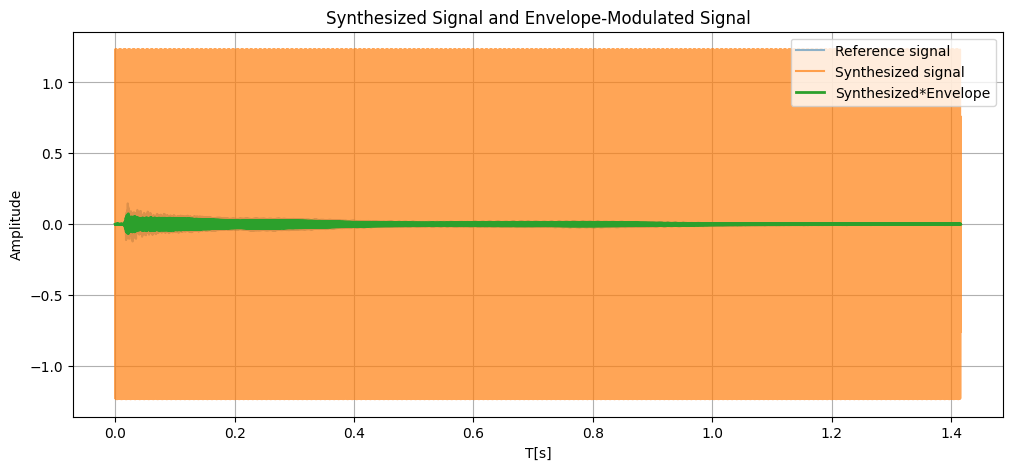

In [3]:
!git clone https://github.com/davidperaltaf/sis1-group202
filepath = "./sis1-group202/labs/audio/sound.wav"
ref, fs = load_audio(filepath)

N = 100
env = envelope(ref, N)

t = np.arange(len(env)) / fs
weights = [0.2762002, 1, 0.06239747, 0.009533455, 0.002722459, 0.002277515, 0.001047189]

phi = 0
f0 = 776 

syn = synthesize(f0, phi, weights, t)
syn_env = syn * env

plt.figure(figsize=(12,5))
plt.plot(t, ref[:len(t)], label="Reference signal", alpha=0.5)
plt.plot(t, syn, label="Synthesized signal", alpha=0.7)
plt.plot(t, syn_env, label="Synthesized*Envelope", linewidth=2)
plt.xlabel("T[s]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.title("Synthesized Signal and Envelope-Modulated Signal")
plt.show()

---

**2. Averaging filter**

Now let's analyze the frequency response of the average filter used in the envelope function. The Scipy Python module has a function called *freqz()* for computing the frequency
response of a discrete-time LTI system. The following Python statements show how to
use freqz to compute and plot both the magnitude (absolute value) and the phase of
the frequency response of a four-point averaging system as a function of ω in the range − π ≤ ω ≤ π :

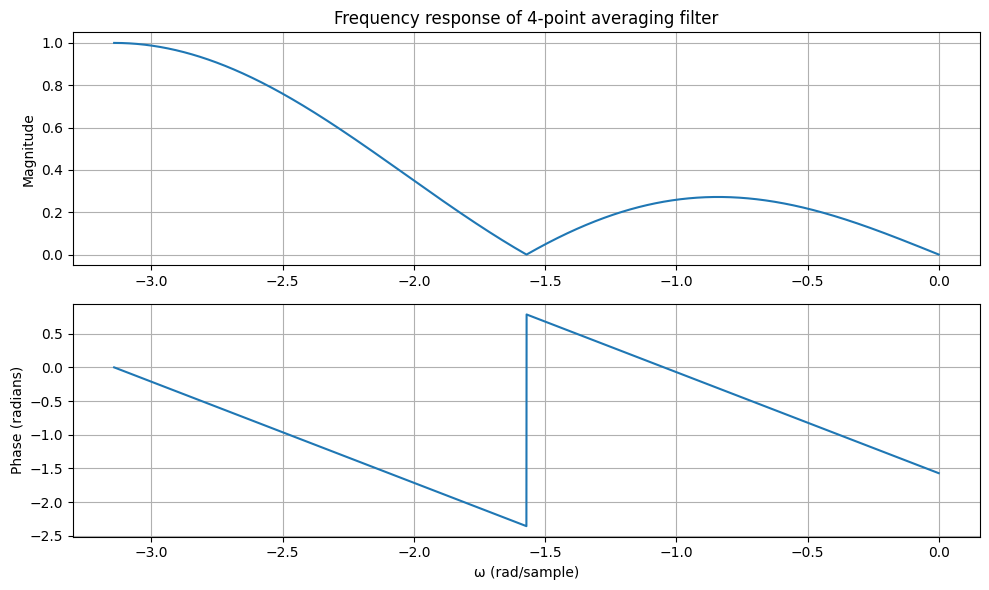

In [4]:
from scipy.signal import freqz
h = np.ones(4) / 4

# Calcula la resposta en freqüència
w, H = freqz(h, worN=8000)  # worN = nombre de punts en el vector de freqüències

# Converteix w (radians/mostra) a interval [-π, π]
w_shifted = np.unwrap(w - np.pi)

# Dibuixa magnitud i fase
plt.figure(figsize=(10,6))

# Magnitud
plt.subplot(2,1,1)
plt.plot(w - np.pi, np.abs(H))
plt.title("Frequency response of 4-point averaging filter")
plt.ylabel("Magnitude")
plt.grid(True)

# Fase
plt.subplot(2,1,2)
plt.plot(w - np.pi, np.angle(H))
plt.ylabel("Phase (radians)")
plt.xlabel("ω (rad/sample)")
plt.grid(True)

plt.tight_layout()
plt.show()

For FIR filters, the second argument of `freqz(-, 1,- )` must always be equal to 1. The frequency vector ww should cover an interval of length 2π for ω , and its spacing must be fine enough to give a smooth curve for H(ejω) . Note: we will always use capital H for the frequency response.

2.1 Use the `freqz` and `plot_frequency_response` functions to plot the frequency response of the averaging filter of your envelope function.



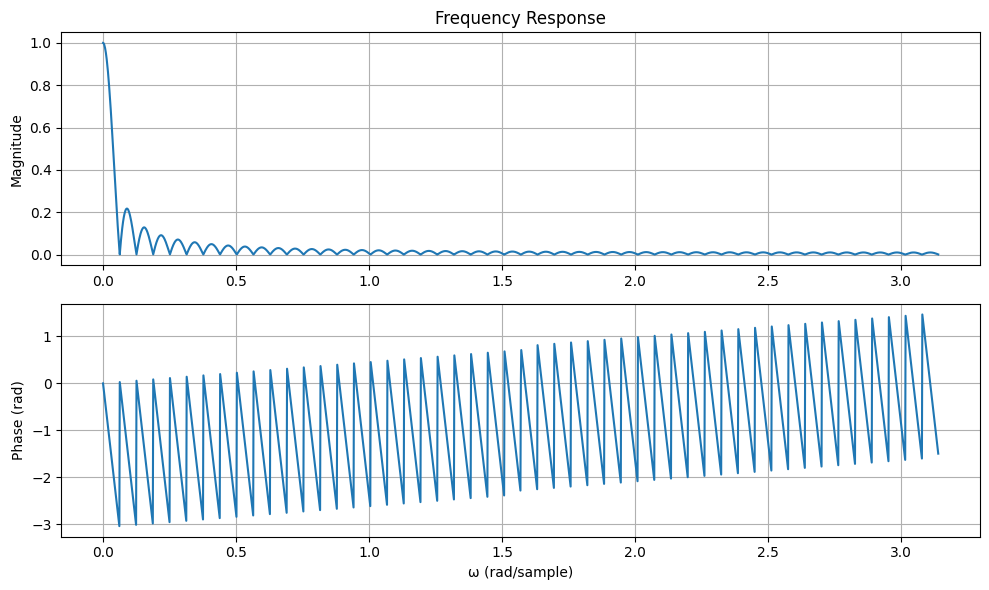

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz

def plot_frequency_response(b):
    """
    Plots the magnitude and phase response of a discrete-time LTI system 
    defined by numerator coefficients b.
    """

    w, H = freqz(b, worN=2048)  # resposta en freqüència

    plt.figure(figsize=(10,6))

    # Magnitud
    plt.subplot(2,1,1)
    plt.plot(w, np.abs(H))
    plt.title("Frequency Response")
    plt.ylabel("Magnitude")
    plt.grid(True)

    # Fase
    plt.subplot(2,1,2)
    plt.plot(w, np.angle(H))
    plt.xlabel("ω (rad/sample)")
    plt.ylabel("Phase (rad)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

N = 100                               # mateix N que fas servir al envelope()
b = np.ones(N) / N                    # filtre d'N punts

plot_frequency_response(b)            # crida la funció



2.2 Looking at the frequency responses, what are the main differences between your filter and the four-point averaging filter. What happens when the value N is increased?

[Double click to write your answer]

---

**3. Nulling Filters for Rejection**

Nulling filters are filters that completely eliminate some frequency components. If the frequency is $\omega=0$ or $\omega=\pi$ then a two-point FIR filter will do the nulling. The simplest possible general nulling filter can have as few as three coefficients. If $\omega_n$ is the desired nulling frequency, then the following length-3 FIR filter

$$
y[n] = x[n] - 2\cos(\omega_n)x[n-1] + x[n-2] 
$$

will have a zero in its frequency response at $\omega=\omega_n$. For example, a filter designed to completely eliminate signals of the form $e^{j0.5\pi}$ would have the following coefficients because we would pick the desired nulling frequency to be $\omega_n = 0.5\pi$

$$
b_0 = 1, \quad b1=-2cos(\omega_n)=0, \quad b_2=1
$$

3.1 Use the following function to add an interference in your reference signal. Name the corrupted signal as `x_interf`.

In [39]:
def add_interference(x, fs):
    """
    Adds a sinusoidal interference at frequency fs/4 (ω = 0.5π)
    to the signal x.

    Parameters
    ----------
    x : np.array
        Input clean signal
    fs : int or float
        Sampling frequency

    Returns
    -------
    x_interf : np.array
        Signal with interference added
    """

    n = np.arange(len(x))
    f_interf = fs / 4         
    interference = 0.5 * np.sin(2 * np.pi * f_interf * n / fs)

    x_interf = x + interference
    return x_interf


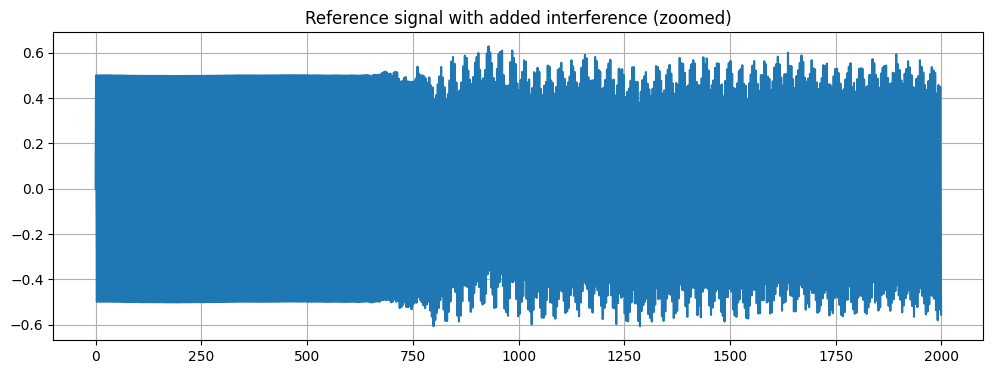

In [7]:
x_interf = add_interference(ref, fs)

plt.figure(figsize=(12,4))
plt.plot(x_interf[:2000])
plt.title("Reference signal with added interference (zoomed)")
plt.grid(True)
plt.show()

3.2 Plot both the reference signal and the corrupted signal and listen to the latter one. 

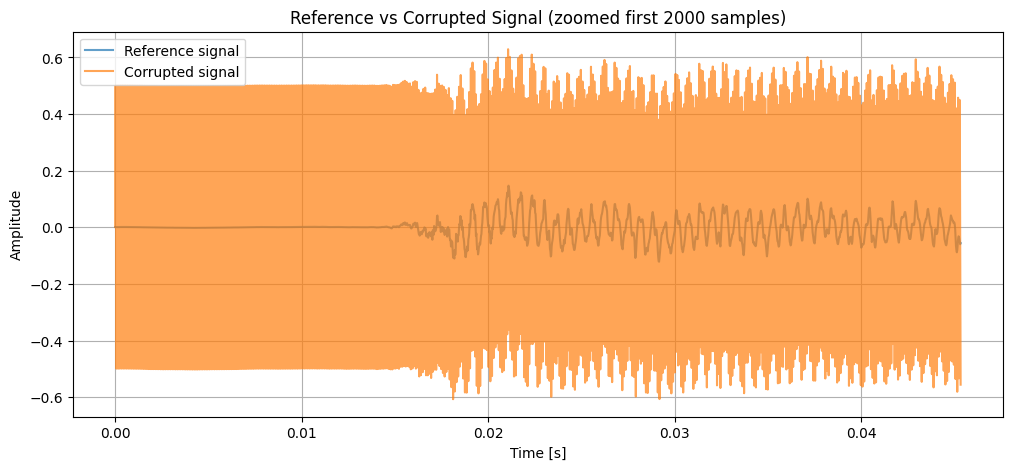

In [ ]:
from IPython.display import Audio


x_interf = add_interference(ref, fs)

t = np.arange(len(ref)) / fs

plt.figure(figsize=(12,5))
plt.plot(t[:2000], ref[:2000], label="Reference signal", alpha=0.7)
plt.plot(t[:2000], x_interf[:2000], label="Corrupted signal", alpha=0.7)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Reference vs Corrupted Signal (zoomed first 2000 samples)")
plt.legend()
plt.grid(True)
plt.show()

Audio(x_interf, rate=fs)

3.3 Compare the spectrograms of the reference signal and the interference signal. 

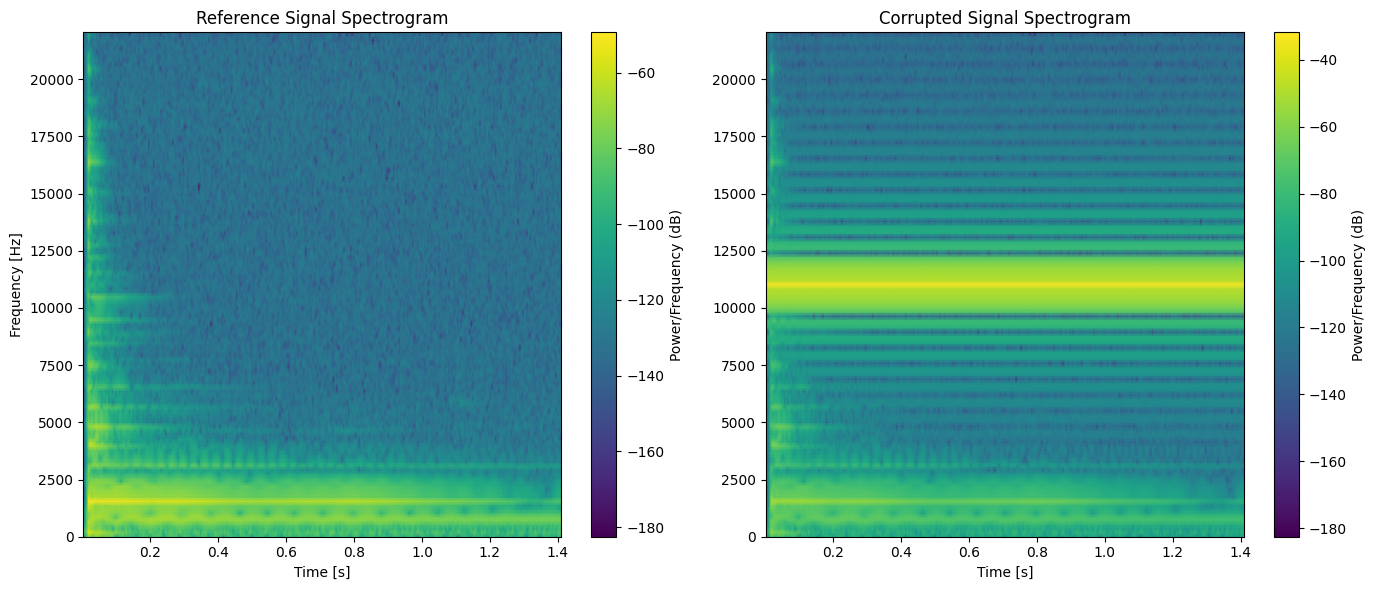

In [ ]:
from scipy.signal import spectrogram

f_ref, t_ref, Sxx_ref = spectrogram(ref, fs)
f_int, t_int, Sxx_int = spectrogram(x_interf, fs)

plt.figure(figsize=(14,6))

plt.subplot(1, 2, 1)
plt.pcolormesh(t_ref, f_ref, 10*np.log10(Sxx_ref), shading='gouraud')
plt.title("Reference Signal Spectrogram")
plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [s]")
plt.colorbar(label='Power/Frequency (dB)')

plt.subplot(1, 2, 2)
plt.pcolormesh(t_int, f_int, 10*np.log10(Sxx_int), shading='gouraud')
plt.title("Corrupted Signal Spectrogram")
plt.xlabel("Time [s]")
plt.colorbar(label='Power/Frequency (dB)')

plt.tight_layout()
plt.show()

3.4. Create a function `remove_interference(x, fs)` that applies a nulling filter devised to remove the interference at 1000 Hz. 

Note: remember that a frequency can be converted to the normalized radian frequncy by: $\omega_n = 2\pi f_n/f_s$

In [ ]:
def remove_interference(x, fs):
    """
    Applies a 3-point nulling filter to remove an interference at 1000 Hz.

    Parameters
    ----------
    x : np.array
        Input signal
    fs : float
        Sampling frequency

    Returns
    -------
    y : np.array
        Filtered signal
    """


    f_interf = 11000
    omega_n = 2*np.pi * f_interf / fs
    b0 = 1
    b1 = -2 * np.cos(omega_n)
    b2 = 1
    b = np.array([b0, b1, b2])

    y = np.convolve(x, b, mode='same')

    return y


3.5 Use the `remove_interference` funcion to clean the corrupted signal,  `x_interf`. Call the output as `x_clean`. Compare the spectrograms of both signals. Explain the result.

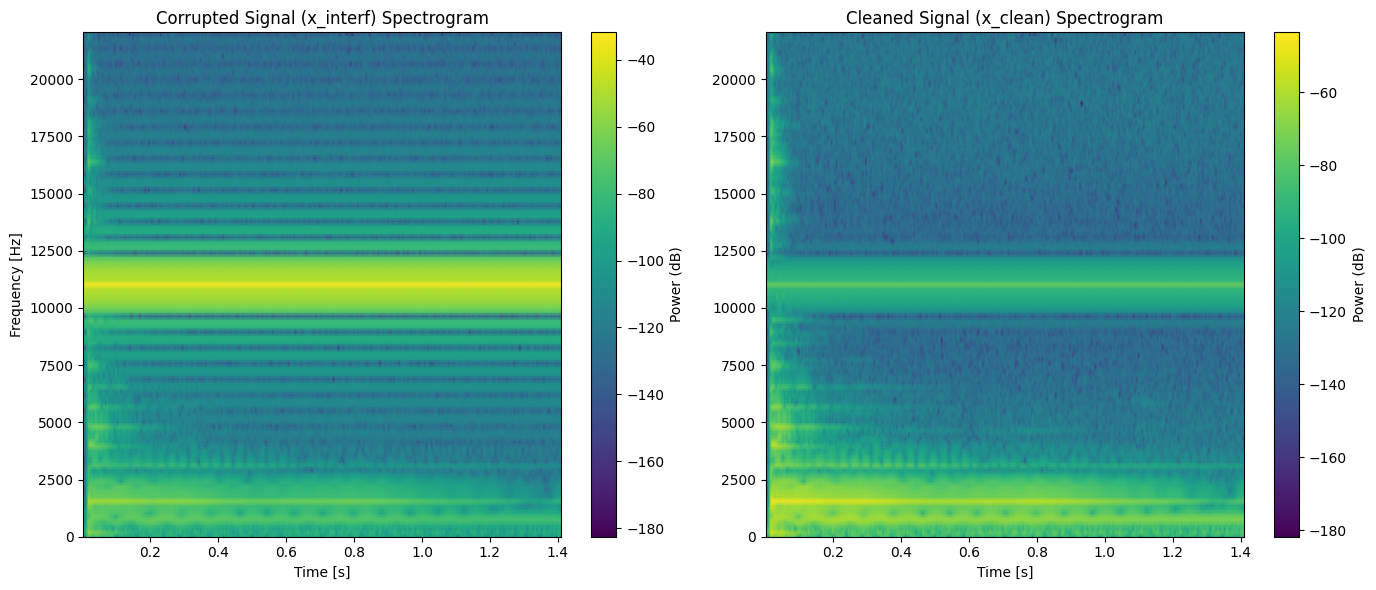

In [ ]:
x_clean = remove_interference(x_interf, fs)

import matplotlib.pyplot as plt
from scipy.signal import spectrogram

f_int, t_int, Sxx_int = spectrogram(x_interf, fs)
f_cln, t_cln, Sxx_cln = spectrogram(x_clean, fs)


plt.figure(figsize=(14,6))

# Corrupted
plt.subplot(1,2,1)
plt.pcolormesh(t_int, f_int, 10*np.log10(Sxx_int), shading='gouraud')
plt.title("Corrupted Signal (x_interf) Spectrogram")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.colorbar(label="Power (dB)")

# Cleaned
plt.subplot(1,2,2)
plt.pcolormesh(t_cln, f_cln, 10*np.log10(Sxx_cln), shading='gouraud')
plt.title("Cleaned Signal (x_clean) Spectrogram")
plt.xlabel("Time [s]")
plt.colorbar(label="Power (dB)")

plt.tight_layout()
plt.show()

Audio(x_clean, rate=fs)
